# Law of Sines — The Rotating Sides Proof

We prove that for any triangle with sides $a$, $b$, $c$ opposite angles $A$, $B$, $C$:

$$\frac{a}{\sin A} = \frac{b}{\sin B} = \frac{c}{\sin C}$$

using the same **tilt-from-90°** thinking as our Law of Cosines proof. In that proof, $\cos(\theta)$ rescaled a side **horizontally** — its projection onto the base. Now, $\sin(\theta)$ rescales a side **vertically** — its projection onto the height.

**The core idea:** Think of each side as a rod rotating like a clock hand. When it's at 90° (straight up), its full length IS the height. As you tilt it, $\sin(\text{angle})$ tells you what fraction of that length still reaches up to $h$.

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from matplotlib.patches import FancyArrowPatch, Arc

## Step 1 — Recall: In Cosines, We Tilted and Watched the Horizontal Projection

In the Law of Cosines notebook, we started with a right angle (90°) and **tilted** side $b$:

- At 90°: $b$ is perpendicular to $a$, so it has **zero** horizontal projection → $\cos(90°) = 0$ → Pythagorean theorem
- As you tilt $b$ away from 90°: $b\cos(\theta)$ measures "how much of $b$ aligns with $a$"
- That horizontal projection is what created the $-2ab\cos(\theta)$ correction term

**Now flip the question:** instead of asking "how much of $b$ aligns with $a$" (horizontal), ask:

> **"How much of $b$ reaches straight UP?"** — that's the height!

The answer is $b \sin(\theta)$. And this is the key to the Law of Sines.

| Projection | Rescaler | At 90° | At 0° | What it controls |
|:-:|:-:|:-:|:-:|:-:|
| Horizontal (onto $a$) | $\cos(\theta)$ | 0 (none) | 1 (full) | Law of **Cosines** |
| Vertical (the height) | $\sin(\theta)$ | 1 (full) | 0 (none) | Law of **Sines** |

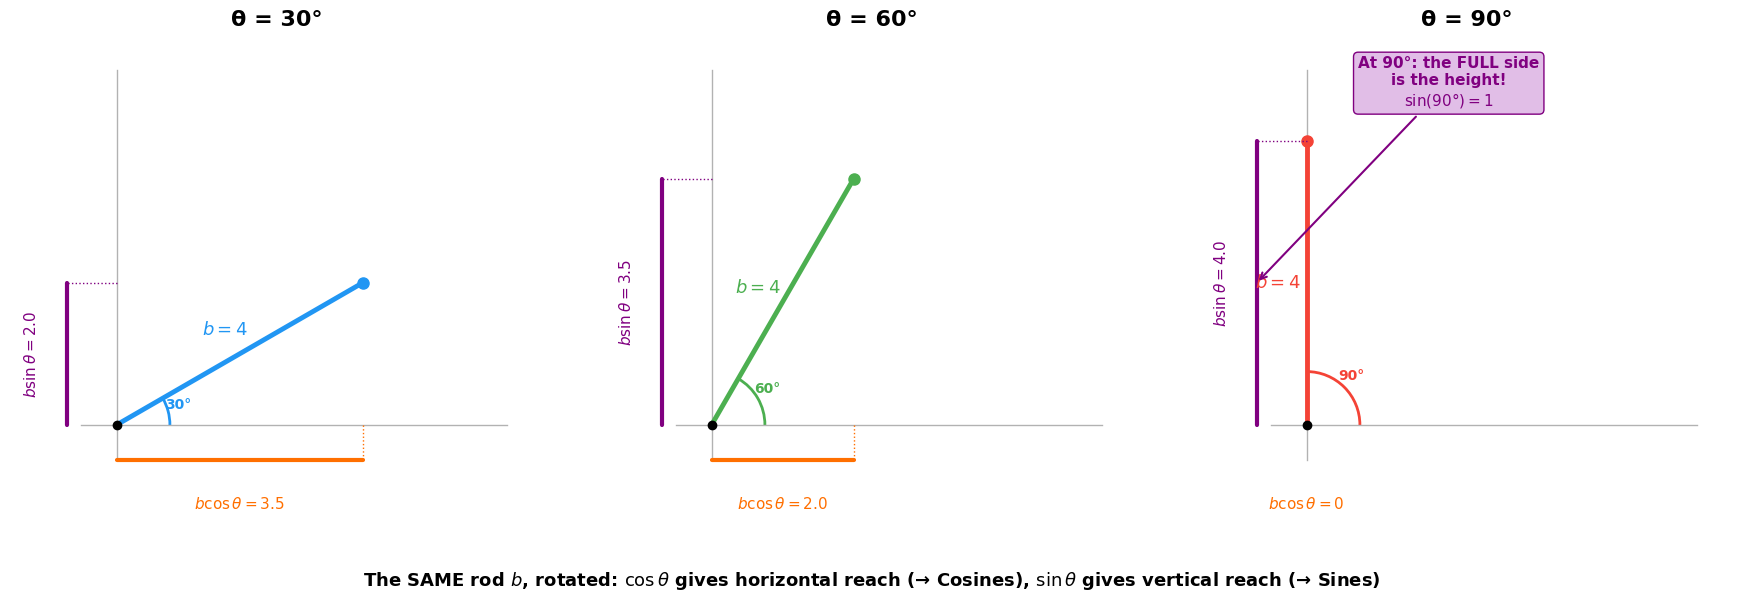

In [15]:
# === DIAGRAM 1: The dual projections — cos gives horizontal, sin gives vertical ===
# Side-by-side: the SAME tilt, but showing both projections

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

b_len = 4
angles_deg = [30, 60, 90]
colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, theta_deg, col in zip(axes, angles_deg, colors):
    theta = np.radians(theta_deg)
    
    ax.set_xlim(-1.5, 6)
    ax.set_ylim(-2, 5.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'θ = {theta_deg}°', fontsize=16, fontweight='bold')
    
    # Base line (the ground)
    ax.plot([-0.5, 5.5], [0, 0], 'k-', lw=1, alpha=0.3)
    ax.plot([0, 0], [-0.5, 5], 'k-', lw=1, alpha=0.3)  # vertical reference
    
    # The side b as a rotating rod from the origin
    bx = b_len * np.cos(theta)
    by = b_len * np.sin(theta)
    ax.plot([0, bx], [0, by], color=col, lw=3.5, solid_capstyle='round')
    ax.plot(bx, by, 'o', color=col, ms=8)
    
    # Label the rod
    mid = np.array([bx, by]) / 2
    offset = np.array([-np.sin(theta), np.cos(theta)]) * 0.4
    ax.text(mid[0] + offset[0], mid[1] + offset[1], f'$b = {b_len}$',
            fontsize=13, fontweight='bold', color=col, ha='center', va='center')
    
    # Horizontal projection: b·cos(θ) — what we used in Law of Cosines
    if abs(bx) > 0.1:
        ax.plot([0, bx], [-0.5, -0.5], color='#FF6F00', lw=3, solid_capstyle='round')
        ax.plot([bx, bx], [0, -0.5], '#FF6F00', lw=1, ls=':')
        ax.text(bx / 2, -1.0, f'$b\\cos θ = {bx:.1f}$',
                fontsize=11, ha='center', va='top', color='#FF6F00', fontweight='bold')
    else:
        ax.text(0, -1.0, '$b\\cos θ = 0$', fontsize=11, ha='center', va='top',
                color='#FF6F00', fontweight='bold')
    
    # Vertical projection: b·sin(θ) — what we use in Law of Sines!
    ax.plot([-0.7, -0.7], [0, by], color='purple', lw=3, solid_capstyle='round')
    ax.plot([0, -0.7], [by, by], 'purple', lw=1, ls=':')
    ax.text(-1.2, by / 2, f'$b\\sin θ = {by:.1f}$',
            fontsize=11, ha='center', va='center', color='purple', fontweight='bold',
            rotation=90)
    
    # The height label
    if theta_deg == 90:
        ax.annotate('At 90°: the FULL side\nis the height!\n$\\sin(90°) = 1$',
                    xy=(-0.7, by / 2), xytext=(2, 4.5),
                    fontsize=11, ha='center', fontweight='bold', color='purple',
                    arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
                    bbox=dict(fc='#E1BEE7', ec='purple', boxstyle='round,pad=0.3'))
    
    # Angle arc
    arc = patches.Arc((0, 0), 1.5, 1.5, angle=0, theta1=0, theta2=theta_deg,
                       lw=2, color=col)
    ax.add_patch(arc)
    ax.text(0.9 * np.cos(np.radians(theta_deg / 2)),
            0.9 * np.sin(np.radians(theta_deg / 2)),
            f'{theta_deg}°', fontsize=10, ha='center', color=col, fontweight='bold')
    
    # Origin dot
    ax.plot(0, 0, 'ko', ms=6)

fig.suptitle('The SAME rod $b$, rotated: $\\cos θ$ gives horizontal reach (→ Cosines), '
             '$\\sin θ$ gives vertical reach (→ Sines)',
             fontsize=13, fontweight='bold', y=0.02)
plt.tight_layout()
plt.show()

## Step 2 — Start at 90°: When a Side IS the Height

Just like the Cosines proof started at 90°, let's start there too.

**Imagine a right triangle.** Side $b$ is perfectly vertical — it goes straight up from the base. In this case:
- The height $h$ of the triangle equals the **full length** of $b$
- Why? Because $h = b \sin(90°) = b \times 1 = b$

**$\sin(90°) = 1$ means: "100% of the side reaches up to the height."**

Now think about the other side $a$ coming down from the top. It sits across from angle $A$. In a right triangle where $B = 90°$:
- $h = a \sin(B) = a \sin(90°) = a$... wait, that would mean $h = a$ too?

No! Remember: $h = a \sin(B)$ only when $B$ is the angle **at the base** that side $a$ "leans from." In a right triangle with the right angle at vertex $B$:
- $h = b \sin(A)$ ← side $b$ projected through angle $A$
- $h = a \sin(B) = a \times 1 = a$... but $a$ isn't the height here, $b$ is!

Let's be precise. **Both sides project onto the same height $h$ through their own angles.** The right triangle is the simplest case where one side does zero work ($\sin = 1$, full length = height).

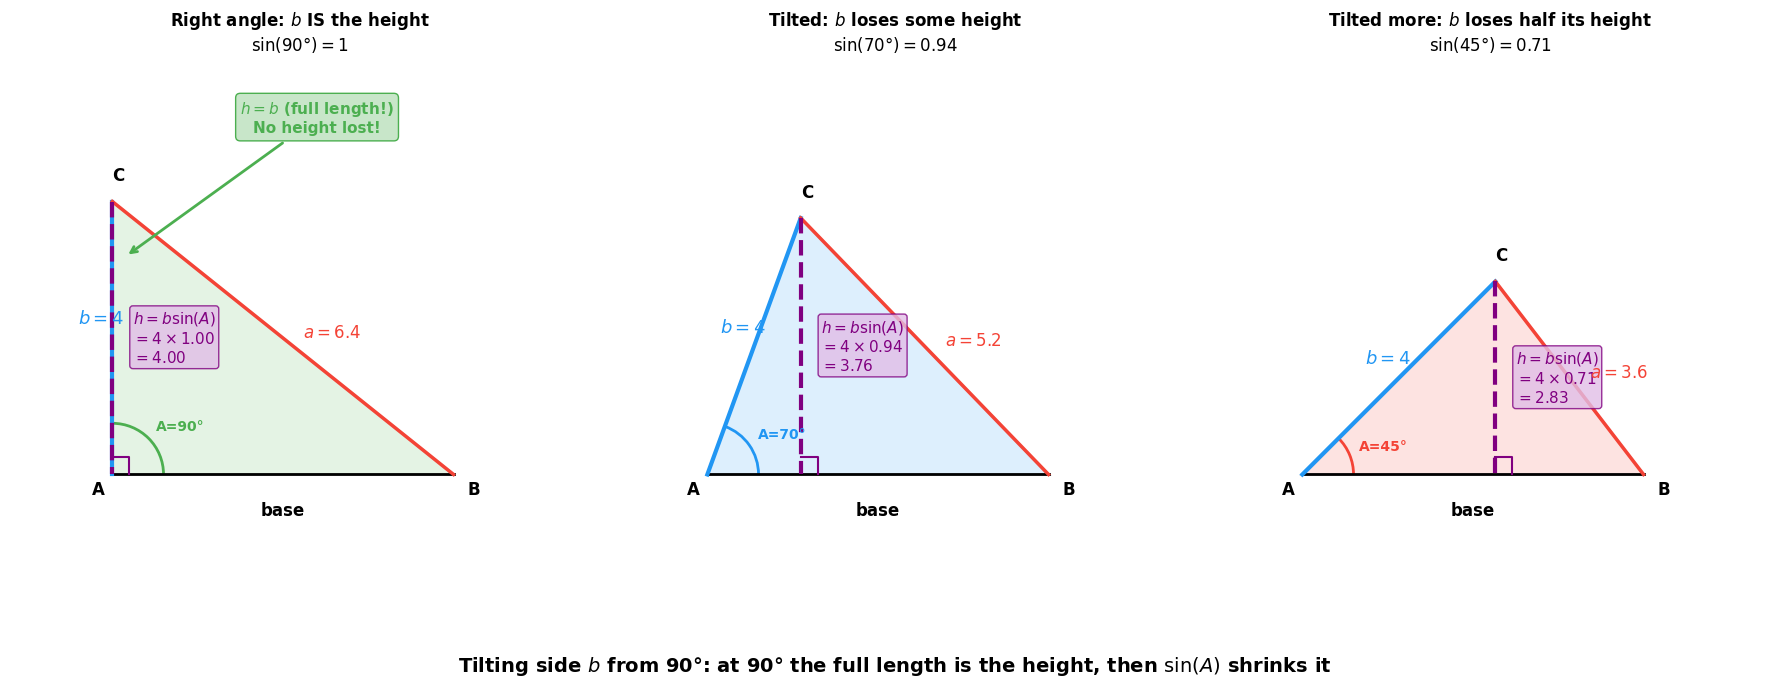

In [23]:
# === DIAGRAM 2: Start at 90° — when a side IS the height ===

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

a_len, b_len = 3, 4
base = 5

# Case 1: Right angle at vertex (b is vertical = height)
# Case 2: Tilted slightly from 90°
# Case 3: Tilted more
cases = [
    (90, 'Right angle: $b$ IS the height\n$\\sin(90°) = 1$'),
    (70, 'Tilted: $b$ loses some height\n$\\sin(70°) = 0.94$'),
    (45, 'Tilted more: $b$ loses half its height\n$\\sin(45°) = 0.71$'),
]
colors = ['#4CAF50', '#2196F3', '#F44336']

for ax, (A_deg, title), col in zip(axes, cases, colors):
    A_rad = np.radians(A_deg)
    
    ax.set_xlim(-1.5, 7)
    ax.set_ylim(-2, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    
    # Place the triangle: A at origin, base along x-axis
    A_pt = np.array([0, 0])
    # Side b goes from A at angle A_deg to the horizontal
    C_pt = np.array([b_len * np.cos(A_rad), b_len * np.sin(A_rad)])
    # B on the x-axis at some distance
    # For this demo, fix B so the triangle looks good
    B_pt = np.array([5, 0])
    
    # Side a = from B to C
    a_val = np.linalg.norm(B_pt - C_pt)
    
    # Draw the triangle
    ax.add_patch(plt.Polygon([A_pt, B_pt, C_pt], fc=col, ec='black', lw=2, alpha=0.15))
    ax.plot([A_pt[0], B_pt[0]], [A_pt[1], B_pt[1]], 'k-', lw=2)
    ax.plot([A_pt[0], C_pt[0]], [A_pt[1], C_pt[1]], color='#2196F3', lw=3)
    ax.plot([B_pt[0], C_pt[0]], [B_pt[1], C_pt[1]], color='#F44336', lw=2.5)
    
    # Drop the height from C
    h = b_len * np.sin(A_rad)
    foot = np.array([C_pt[0], 0])
    ax.plot([C_pt[0], foot[0]], [C_pt[1], 0], color='purple', lw=3, ls='--')
    
    # Right angle marker
    sq = 0.25
    ax.plot([foot[0] + sq, foot[0] + sq, foot[0]], [0, sq, sq], 'purple', lw=1.5)
    
    # Height label
    ax.text(C_pt[0] + 0.3, h / 2,
            f'$h = b\\sin(A)$\n$= {b_len} \\times {np.sin(A_rad):.2f}$\n$= {h:.2f}$',
            fontsize=11, ha='left', va='center', color='purple', fontweight='bold',
            bbox=dict(fc='#E1BEE7', ec='purple', boxstyle='round,pad=0.2', alpha=0.8))
    
    # Side labels
    mid_b = (A_pt + C_pt) / 2
    ax.text(mid_b[0] - 0.5, mid_b[1] + 0.2, f'$b = {b_len}$',
            fontsize=13, fontweight='bold', color='#2196F3')
    mid_a = (B_pt + C_pt) / 2
    ax.text(mid_a[0] + 0.3, mid_a[1], f'$a = {a_val:.1f}$',
            fontsize=12, fontweight='bold', color='#F44336')
    ax.text(2.5, -0.4, 'base', fontsize=12, ha='center', va='top', fontweight='bold')
    
    # Angle arc
    arc = patches.Arc(A_pt, 1.5, 1.5, angle=0, theta1=0, theta2=A_deg, lw=2, color=col)
    ax.add_patch(arc)
    ax.text(0.9 * np.cos(np.radians(A_deg / 2)),
            0.9 * np.sin(np.radians(A_deg / 2)),
            f'A={A_deg}°', fontsize=10, color=col, fontweight='bold')
    
    # Vertex labels
    ax.text(-0.3, -0.3, 'A', fontsize=12, fontweight='bold')
    ax.text(B_pt[0] + 0.2, -0.3, 'B', fontsize=12, fontweight='bold')
    ax.text(C_pt[0], C_pt[1] + 0.3, 'C', fontsize=12, fontweight='bold')
    
    # For the 90° case, highlight that h = b
    if A_deg == 90:
        ax.annotate('$h = b$ (full length!)\nNo height lost!',
                    xy=(C_pt[0] + 0.2, h * 0.8), xytext=(3, 5),
                    fontsize=11, ha='center', fontweight='bold', color='#4CAF50',
                    arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2),
                    bbox=dict(fc='#C8E6C9', ec='#4CAF50', boxstyle='round,pad=0.3'))

fig.suptitle('Tilting side $b$ from 90°: at 90° the full length is the height, '
             'then $\\sin(A)$ shrinks it',
             fontsize=14, fontweight='bold', y=0.02)
plt.tight_layout()
plt.show()

## Step 3 — The Circle View: Each Side is a Rotating Rod

Here's the "Aha!" Think of each side as a **rod pinned at one end of the base**, free to rotate like a clock hand.

**Side $b$ rotates from vertex $A$** at angle $A$ above the base:
- Its tip traces a **circle of radius $b$**
- The height it reaches: $h = b \sin(A)$
- At $A = 90°$: full reach → $h = b$
- At $A = 30°$: half reach → $h = b/2$

**Side $a$ rotates from vertex $B$** at angle $B$ above the base:
- Its tip traces a **circle of radius $a$**
- The height it reaches: $h = a \sin(B)$
- At $B = 90°$: full reach → $h = a$
- At $B = 30°$: half reach → $h = a/2$

**But their tips must MEET at the same point $C$!** That means they must reach the **same height**:

$$b \sin(A) = a \sin(B)$$

Two rods, two different circles, two different angles — but they're **forced** to agree on the height because they both end at vertex $C$. This is the Law of Sines.

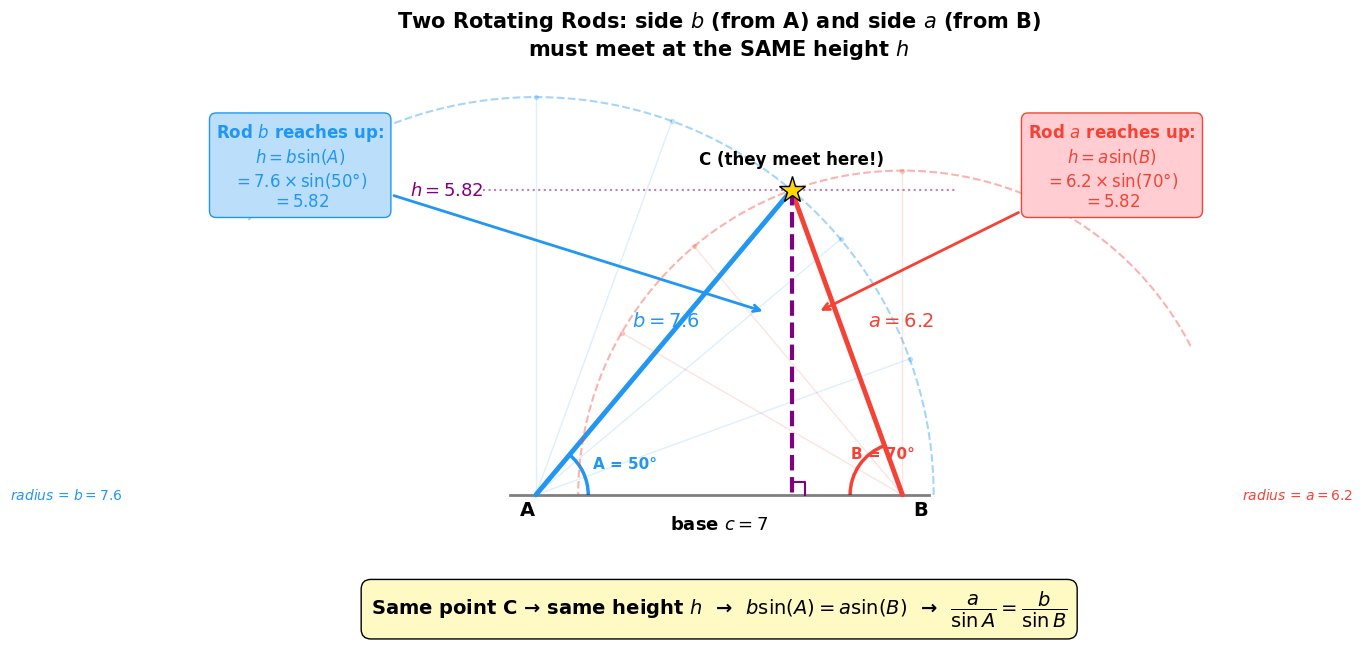

In [24]:
# === DIAGRAM 3: The Circle View — two rotating rods must meet at the same height ===

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

# Triangle setup
A_deg, B_deg = 50, 70
C_deg = 180 - A_deg - B_deg
A_rad, B_rad = np.radians(A_deg), np.radians(B_deg)

c_base = 7
a_len = c_base * np.sin(A_rad) / np.sin(np.radians(C_deg))
b_len = c_base * np.sin(B_rad) / np.sin(np.radians(C_deg))

A_pt = np.array([0, 0])
B_pt = np.array([c_base, 0])
C_pt = np.array([b_len * np.cos(A_rad), b_len * np.sin(A_rad)])
h = b_len * np.sin(A_rad)

ax.set_xlim(-5.5, 12.5)
ax.set_ylim(-3, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('Two Rotating Rods: side $b$ (from A) and side $a$ (from B)\n'
             'must meet at the SAME height $h$',
             fontsize=15, fontweight='bold', pad=15)

# Draw the base
ax.plot([A_pt[0] - 0.5, B_pt[0] + 0.5], [0, 0], 'k-', lw=2, alpha=0.5)
ax.text(c_base / 2, -0.4, f'base $c = {c_base}$', fontsize=13, ha='center',
        va='top', fontweight='bold')

# --- Circle of radius b around A ---
theta_sweep = np.linspace(0, np.pi, 100)
circle_b_x = b_len * np.cos(theta_sweep)
circle_b_y = b_len * np.sin(theta_sweep)
ax.plot(circle_b_x, circle_b_y, color='#2196F3', lw=1.5, ls='--', alpha=0.4)
ax.text(-b_len - 0.3, 0, f'radius = $b = {b_len:.1f}$', fontsize=10,
        ha='right', va='center', color='#2196F3', fontstyle='italic')

# Ghost positions of rod b at different angles
for ghost_deg in [20, 40, 70, 90]:
    ghost_rad = np.radians(ghost_deg)
    gx, gy = b_len * np.cos(ghost_rad), b_len * np.sin(ghost_rad)
    ax.plot([0, gx], [0, gy], color='#2196F3', lw=1, alpha=0.15)
    ax.plot(gx, gy, 'o', color='#2196F3', ms=3, alpha=0.2)

# The actual rod b at angle A
ax.plot([0, C_pt[0]], [0, C_pt[1]], color='#2196F3', lw=3.5, solid_capstyle='round')
ax.plot(C_pt[0], C_pt[1], 'o', color='#2196F3', ms=8)
mid_b = C_pt / 2
ax.text(mid_b[0] - 0.6, mid_b[1] + 0.3, f'$b = {b_len:.1f}$',
        fontsize=14, fontweight='bold', color='#2196F3')

# --- Circle of radius a around B ---
circle_a_x = B_pt[0] + a_len * np.cos(theta_sweep)
circle_a_y = a_len * np.sin(theta_sweep)
ax.plot(circle_a_x, circle_a_y, color='#F44336', lw=1.5, ls='--', alpha=0.4)
ax.text(B_pt[0] + a_len + 0.3, 0, f'radius = $a = {a_len:.1f}$', fontsize=10,
        ha='left', va='center', color='#F44336', fontstyle='italic')

# Ghost positions of rod a at different angles
for ghost_deg in [110, 130, 150, 90]:
    ghost_rad = np.radians(ghost_deg)
    gx = B_pt[0] + a_len * np.cos(ghost_rad)
    gy = a_len * np.sin(ghost_rad)
    ax.plot([B_pt[0], gx], [0, gy], color='#F44336', lw=1, alpha=0.15)
    ax.plot(gx, gy, 'o', color='#F44336', ms=3, alpha=0.2)

# The actual rod a at angle (180 - B) from B
ax.plot([B_pt[0], C_pt[0]], [0, C_pt[1]], color='#F44336', lw=3.5, solid_capstyle='round')
ax.plot(C_pt[0], C_pt[1], 'o', color='#F44336', ms=8)
mid_a = (B_pt + C_pt) / 2
ax.text(mid_a[0] + 0.4, mid_a[1] + 0.3, f'$a = {a_len:.1f}$',
        fontsize=14, fontweight='bold', color='#F44336')

# --- The height h — they MUST agree ---
foot = np.array([C_pt[0], 0])
ax.plot([C_pt[0], foot[0]], [C_pt[1], 0], color='purple', lw=3, ls='--')
sq = 0.25
ax.plot([foot[0] + sq, foot[0] + sq, foot[0]], [0, sq, sq], 'purple', lw=1.5)

# Horizontal dashed line at height h
ax.plot([A_pt[0] - 1, B_pt[0] + 1], [h, h], color='purple', lw=1.5, ls=':', alpha=0.5)
ax.text(-1, h, f'$h = {h:.2f}$', fontsize=13, ha='right', va='center',
        color='purple', fontweight='bold')

# Meeting point
ax.plot(C_pt[0], C_pt[1], '*', color='gold', ms=20, markeredgecolor='black',
        markeredgewidth=1, zorder=10)
ax.text(C_pt[0], C_pt[1] + 0.5, 'C (they meet here!)', fontsize=12,
        ha='center', fontweight='bold', color='black')

# Angle arcs
arc_A = patches.Arc(A_pt, 2, 2, angle=0, theta1=0, theta2=A_deg, lw=2.5, color='#2196F3')
ax.add_patch(arc_A)
ax.text(1.2 * np.cos(np.radians(A_deg / 2)),
        1.2 * np.sin(np.radians(A_deg / 2)),
        f'A = {A_deg}°', fontsize=11, color='#2196F3', fontweight='bold')

arc_B = patches.Arc(B_pt, 2, 2, angle=0, theta1=180 - B_deg, theta2=180, lw=2.5, color='#F44336')
ax.add_patch(arc_B)
ax.text(B_pt[0] - 1.2 * np.cos(np.radians(B_deg / 2)),
        1.2 * np.sin(np.radians(B_deg / 2)),
        f'B = {B_deg}°', fontsize=11, color='#F44336', fontweight='bold')

# Vertex labels
ax.text(-0.3, -0.4, 'A', fontsize=14, fontweight='bold')
ax.text(B_pt[0] + 0.2, -0.4, 'B', fontsize=14, fontweight='bold')

# The two height equations — annotation boxes
ax.annotate(f'Rod $b$ reaches up:\n$h = b \\sin(A)$\n$= {b_len:.1f} \\times \\sin({A_deg}°)$\n$= {b_len * np.sin(A_rad):.2f}$',
            xy=(C_pt[0] - 0.5, h * 0.6), xytext=(-4.5, 5.5),
            fontsize=12, ha='center', color='#2196F3', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2),
            bbox=dict(fc='#BBDEFB', ec='#2196F3', boxstyle='round,pad=0.4'))

ax.annotate(f'Rod $a$ reaches up:\n$h = a \\sin(B)$\n$= {a_len:.1f} \\times \\sin({B_deg}°)$\n$= {a_len * np.sin(B_rad):.2f}$',
            xy=(C_pt[0] + 0.5, h * 0.6), xytext=(11, 5.5),
            fontsize=12, ha='center', color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2),
            bbox=dict(fc='#FFCDD2', ec='#F44336', boxstyle='round,pad=0.4'))

# Key equation
ax.text(c_base / 2, -1.8,
        'Same point C → same height $h$  →  $b \\sin(A) = a \\sin(B)$  →  '
        '$\\dfrac{a}{\\sin A} = \\dfrac{b}{\\sin B}$',
        fontsize=14, ha='center', va='top', fontweight='bold',
        bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

## Step 4 — The Tilt Trade-Off: What Gets Lost, What Gets Gained

Just like in the Cosines proof, where tilting from 90° created a "lost area" that became the $2ab\cos\theta$ correction, here tilting from 90° creates a **"lost height"**.

The trade-off is:

- **If angle $A$ gets smaller** (side $b$ tilts toward the base): $\sin(A)$ decreases → $b$'s height contribution drops → but side $a$ must get **longer** to compensate, so $a \sin(B)$ still reaches the same $h$
- **If angle $A$ gets bigger** (side $b$ tilts toward vertical): $\sin(A)$ increases → $b$'s height contribution grows → side $a$ can be **shorter**

Think of it like a see-saw:
- A short side with a big angle (close to 90°) produces the same height as...
- A long side with a small angle (close to 0°)

Because $\sin$ is the rescaler: $\text{side} \times \sin(\text{angle}) = h$ for **every** side-angle pair.

| Angle | $\sin(\text{angle})$ | Side needed for $h = 4$ | Meaning |
|:-:|:-:|:-:|:--|
| 90° | 1.00 | 4.00 | Side = height (no loss) |
| 60° | 0.87 | 4.62 | Side must be 15% longer |
| 45° | 0.71 | 5.66 | Side must be 41% longer |
| 30° | 0.50 | 8.00 | Side must be **double** the height! |

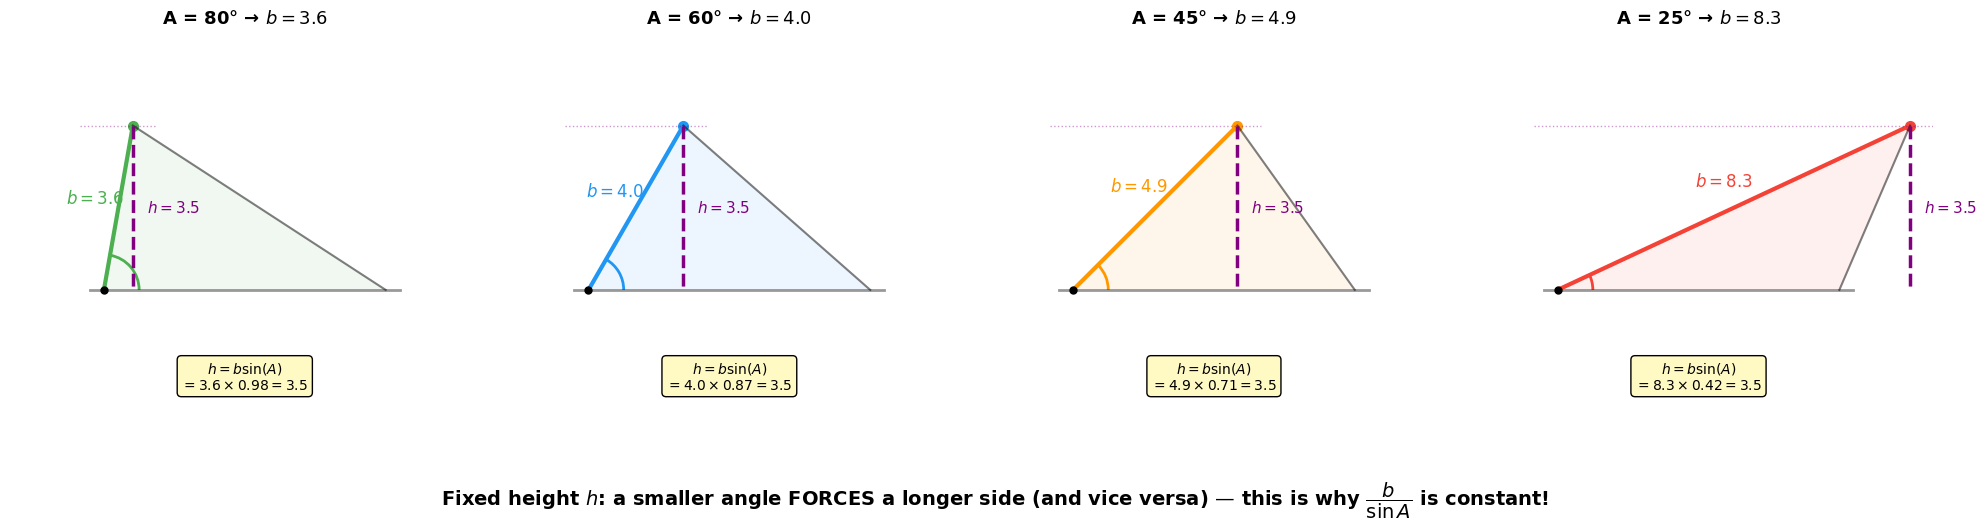

In [18]:
# === DIAGRAM 4: The Tilt Trade-Off — short side + big angle = long side + small angle ===

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# Fix height h and show how different angle-side combos achieve it
h_fixed = 3.5
c_base = 6
# We change angle A: as A decreases, b must grow to keep h = b·sin(A) constant
angles_A = [80, 60, 45, 25]
colors = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']

for ax, A_deg, col in zip(axes, angles_A, colors):
    A_rad = np.radians(A_deg)
    b_needed = h_fixed / np.sin(A_rad)  # b must be this long to reach h
    
    ax.set_xlim(-2, 8)
    ax.set_ylim(-2.5, 5.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'A = {A_deg}° → $b = {b_needed:.1f}$', fontsize=13, fontweight='bold')
    
    # Base
    A_pt = np.array([0, 0])
    B_pt = np.array([c_base, 0])
    ax.plot([A_pt[0] - 0.3, B_pt[0] + 0.3], [0, 0], 'k-', lw=2, alpha=0.4)
    
    # Side b at angle A
    C_pt = np.array([b_needed * np.cos(A_rad), b_needed * np.sin(A_rad)])
    ax.plot([0, C_pt[0]], [0, C_pt[1]], color=col, lw=3)
    ax.plot(C_pt[0], C_pt[1], 'o', color=col, ms=7)
    
    # Label b
    mid = C_pt / 2
    offset = np.array([-np.sin(A_rad), np.cos(A_rad)]) * 0.5
    ax.text(mid[0] + offset[0], mid[1] + offset[1], f'$b = {b_needed:.1f}$',
            fontsize=12, fontweight='bold', color=col, ha='center')
    
    # Close the triangle
    ax.plot([B_pt[0], C_pt[0]], [B_pt[1], C_pt[1]], 'k-', lw=1.5, alpha=0.5)
    ax.add_patch(plt.Polygon([A_pt, B_pt, C_pt], fc=col, ec='none', alpha=0.08))
    
    # Height
    foot = np.array([C_pt[0], 0])
    ax.plot([C_pt[0], foot[0]], [C_pt[1], 0], color='purple', lw=2.5, ls='--')
    ax.text(C_pt[0] + 0.3, h_fixed / 2, f'$h = {h_fixed}$',
            fontsize=11, color='purple', fontweight='bold', va='center')
    
    # Horizontal line at h
    ax.plot([-0.5, C_pt[0] + 0.5], [h_fixed, h_fixed], 'purple', lw=1, ls=':', alpha=0.4)
    
    # Angle arc
    arc = patches.Arc(A_pt, 1.5, 1.5, angle=0, theta1=0, theta2=A_deg, lw=2, color=col)
    ax.add_patch(arc)
    
    # Formula
    ax.text(3, -1.5,
            f'$h = b \\sin(A)$\n$= {b_needed:.1f} \\times {np.sin(A_rad):.2f} = {h_fixed:.1f}$',
            fontsize=10, ha='center', va='top',
            bbox=dict(fc='#FFF9C4', ec='black', boxstyle='round,pad=0.3'))
    
    ax.plot(0, 0, 'ko', ms=5)

fig.suptitle('Fixed height $h$: a smaller angle FORCES a longer side (and vice versa) — '
             'this is why $\\dfrac{b}{\\sin A}$ is constant!',
             fontsize=14, fontweight='bold', y=0.02)
plt.tight_layout()
plt.show()

## Step 5 — The Interactive Sweep: Rotate Both Rods, Watch the Height Lock

This is the key visualisation — the equivalent of the "sweep θ from 30° to 150°" diagram in the Cosines proof.

We keep the base $c$ fixed and slide vertex $C$ left and right. As $C$ moves:
- Angle $A$ changes → $b \sin(A)$ changes
- Angle $B$ changes → $a \sin(B)$ changes
- Sides $a$ and $b$ change length too

But the height $h$ from $C$ to the base stays **exactly the same** if $C$ stays at the same elevation. And even if $C$ moves up or down, the two height calculations are **forced to agree** because they both measure the same perpendicular distance.

Watch the bar chart: $b \sin(A)$ and $a \sin(B)$ are **always identical**.

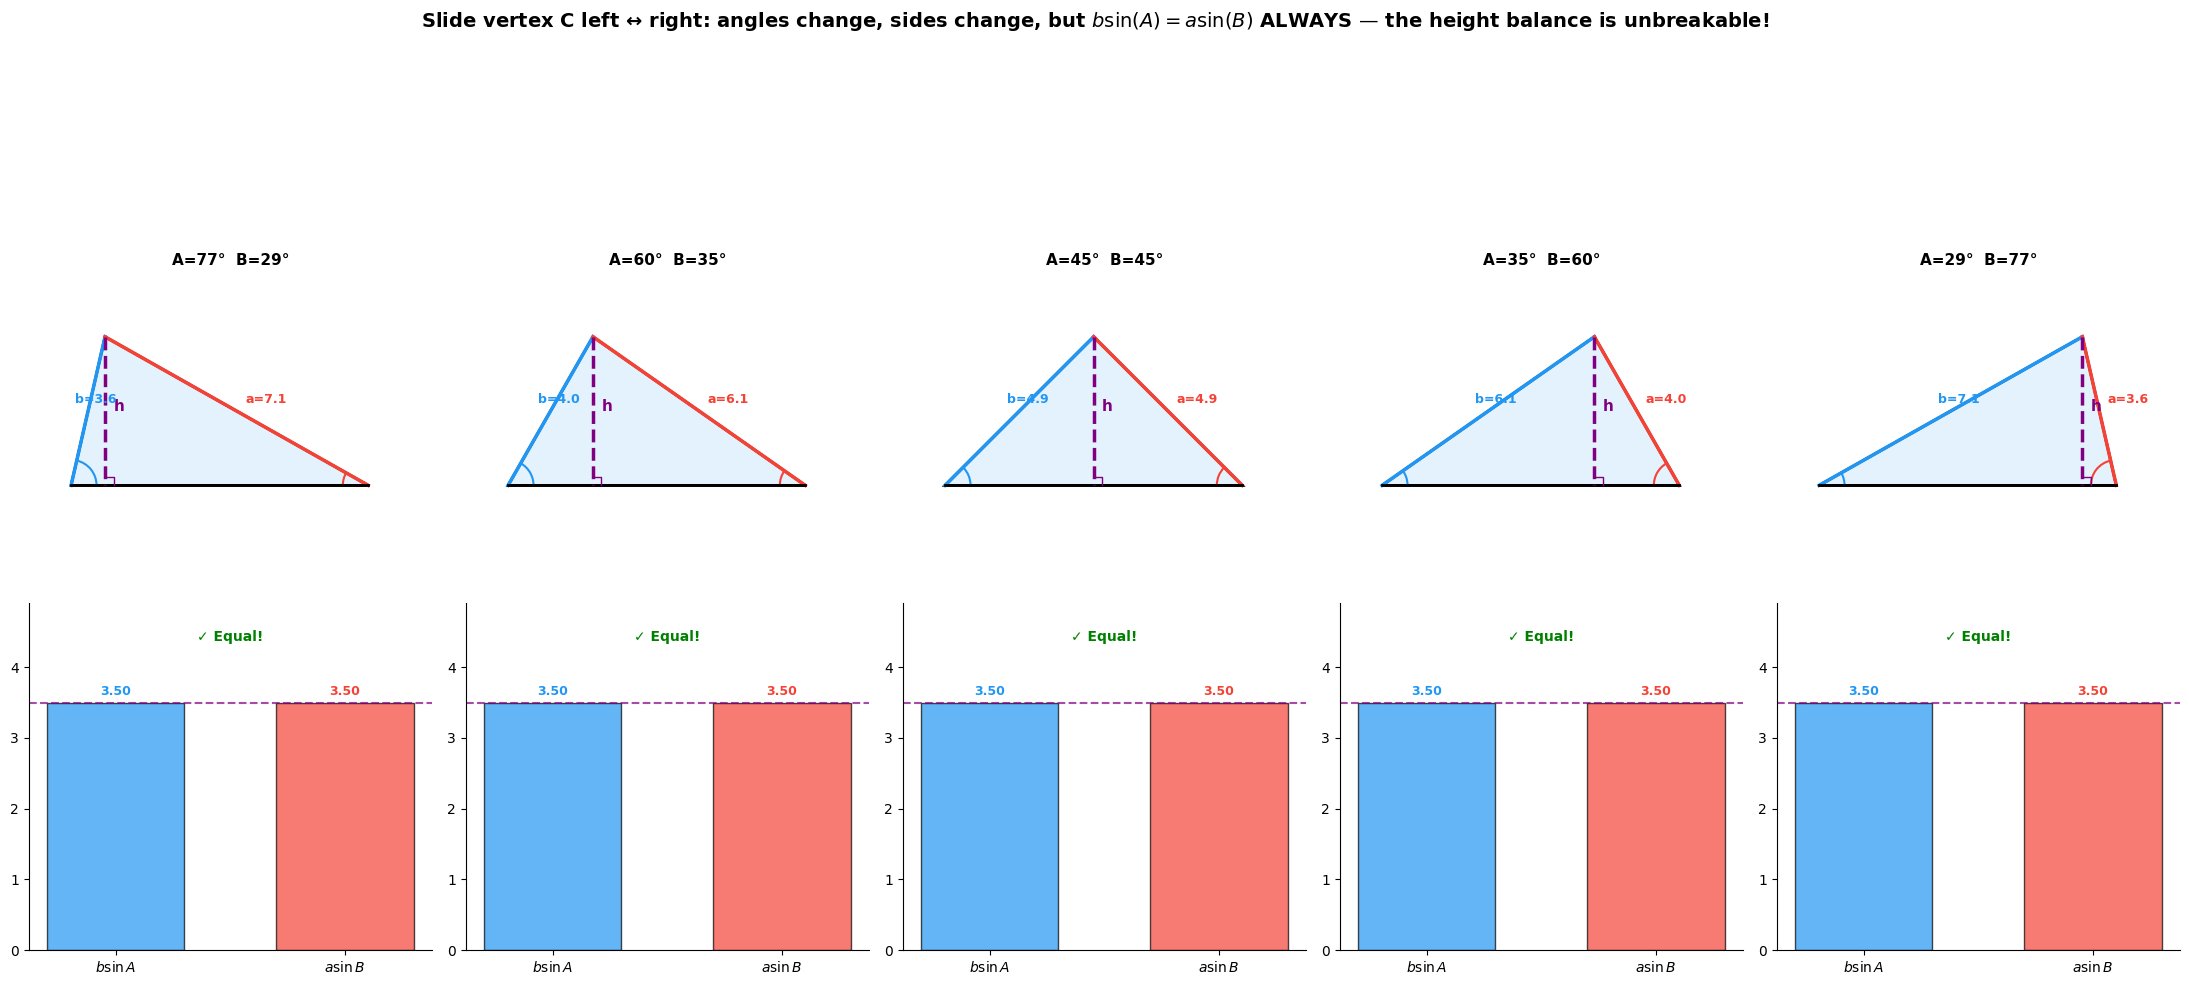

In [19]:
# === DIAGRAM 5: Sweep C's position — both height calculations stay locked ===

c_base = 7
cy_fixed = 3.5
cx_positions = [0.8, 2.0, 3.5, 5.0, 6.2]

fig, axes = plt.subplots(2, 5, figsize=(22, 10),
                         gridspec_kw={'height_ratios': [3, 1.5]})

for i, cx in enumerate(cx_positions):
    ax_tri = axes[0, i]
    ax_bar = axes[1, i]
    
    A_pt = np.array([0, 0])
    B_pt = np.array([c_base, 0])
    C_pt = np.array([cx, cy_fixed])
    
    # Sides
    a_val = np.linalg.norm(B_pt - C_pt)
    b_val = np.linalg.norm(A_pt - C_pt)
    
    # Angles at A and B
    A_angle = np.arctan2(cy_fixed, cx)
    B_angle = np.arctan2(cy_fixed, c_base - cx)
    
    h_from_b = b_val * np.sin(A_angle)
    h_from_a = a_val * np.sin(B_angle)
    
    # Color gradient
    t = i / (len(cx_positions) - 1)
    
    # --- Triangle panel ---
    ax_tri.set_xlim(-1, 8.5)
    ax_tri.set_ylim(-0.5, 5)
    ax_tri.set_aspect('equal')
    ax_tri.axis('off')
    ax_tri.set_title(f'A={np.degrees(A_angle):.0f}°  B={np.degrees(B_angle):.0f}°',
                     fontsize=11, fontweight='bold')
    
    # Draw triangle
    ax_tri.add_patch(plt.Polygon([A_pt, B_pt, C_pt], fc='#E3F2FD', ec='black', lw=2))
    ax_tri.plot([A_pt[0], C_pt[0]], [A_pt[1], C_pt[1]], '#2196F3', lw=2.5)
    ax_tri.plot([B_pt[0], C_pt[0]], [B_pt[1], C_pt[1]], '#F44336', lw=2.5)
    ax_tri.plot([A_pt[0], B_pt[0]], [A_pt[1], B_pt[1]], 'k-', lw=2)
    
    # Height
    ax_tri.plot([cx, cx], [cy_fixed, 0], 'purple', lw=2.5, ls='--')
    sq = 0.2
    ax_tri.plot([cx + sq, cx + sq, cx], [0, sq, sq], 'purple', lw=1)
    ax_tri.text(cx + 0.2, cy_fixed / 2, f'h', fontsize=11, color='purple', fontweight='bold')
    
    # Side labels
    mid_b = C_pt / 2
    ax_tri.text(mid_b[0] - 0.3, mid_b[1] + 0.2, f'b={b_val:.1f}',
                fontsize=9, color='#2196F3', fontweight='bold')
    mid_a = (B_pt + C_pt) / 2
    ax_tri.text(mid_a[0] + 0.2, mid_a[1] + 0.2, f'a={a_val:.1f}',
                fontsize=9, color='#F44336', fontweight='bold')
    
    # Angle arcs
    arc_A = patches.Arc(A_pt, 1.2, 1.2, angle=0, theta1=0,
                        theta2=np.degrees(A_angle), lw=1.5, color='#2196F3')
    ax_tri.add_patch(arc_A)
    arc_B = patches.Arc(B_pt, 1.2, 1.2, angle=0, theta1=180 - np.degrees(B_angle),
                        theta2=180, lw=1.5, color='#F44336')
    ax_tri.add_patch(arc_B)
    
    # --- Bar chart ---
    bars = ax_bar.bar([0, 1], [h_from_b, h_from_a],
                      color=['#2196F3', '#F44336'], edgecolor='black', width=0.6, alpha=0.7)
    ax_bar.set_xticks([0, 1])
    ax_bar.set_xticklabels(['$b\\sin A$', '$a\\sin B$'], fontsize=10)
    ax_bar.set_ylim(0, cy_fixed * 1.4)
    ax_bar.axhline(cy_fixed, color='purple', ls='--', lw=1.5, alpha=0.7)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    
    # Value labels
    ax_bar.text(0, h_from_b + 0.1, f'{h_from_b:.2f}', ha='center', fontsize=9,
                fontweight='bold', color='#2196F3')
    ax_bar.text(1, h_from_a + 0.1, f'{h_from_a:.2f}', ha='center', fontsize=9,
                fontweight='bold', color='#F44336')
    
    # Check mark
    if abs(h_from_b - h_from_a) < 0.01:
        ax_bar.text(0.5, cy_fixed * 1.25, '✓ Equal!', ha='center', fontsize=10,
                    color='green', fontweight='bold')

fig.suptitle('Slide vertex C left ↔ right: angles change, sides change, '
             'but $b\\sin(A) = a\\sin(B)$ ALWAYS — the height balance is unbreakable!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6 — The Full Circle: Where Does $\frac{a}{\sin A} = 2R$ Come From?

Remember the two rods rotating on their circles? There's a deeper truth.

**All triangles with the same base $c$ and the same angle $C$ at the top lie on the same circle.** This is a classic geometry fact — the angle subtended by a chord is constant for all points on the same arc.

The constant ratio $\frac{a}{\sin A} = \frac{b}{\sin B} = \frac{c}{\sin C}$ equals the **diameter** of this circumscribed circle:

$$\frac{a}{\sin A} = 2R$$

**Why?** Because $\sin(A)$ is exactly the fraction of side $b$'s length that becomes the height. The circumscribed circle's diameter is the "maximum possible triangle" for that chord — when the angle is 90°, the side opposite equals the diameter (since $\sin 90° = 1$).

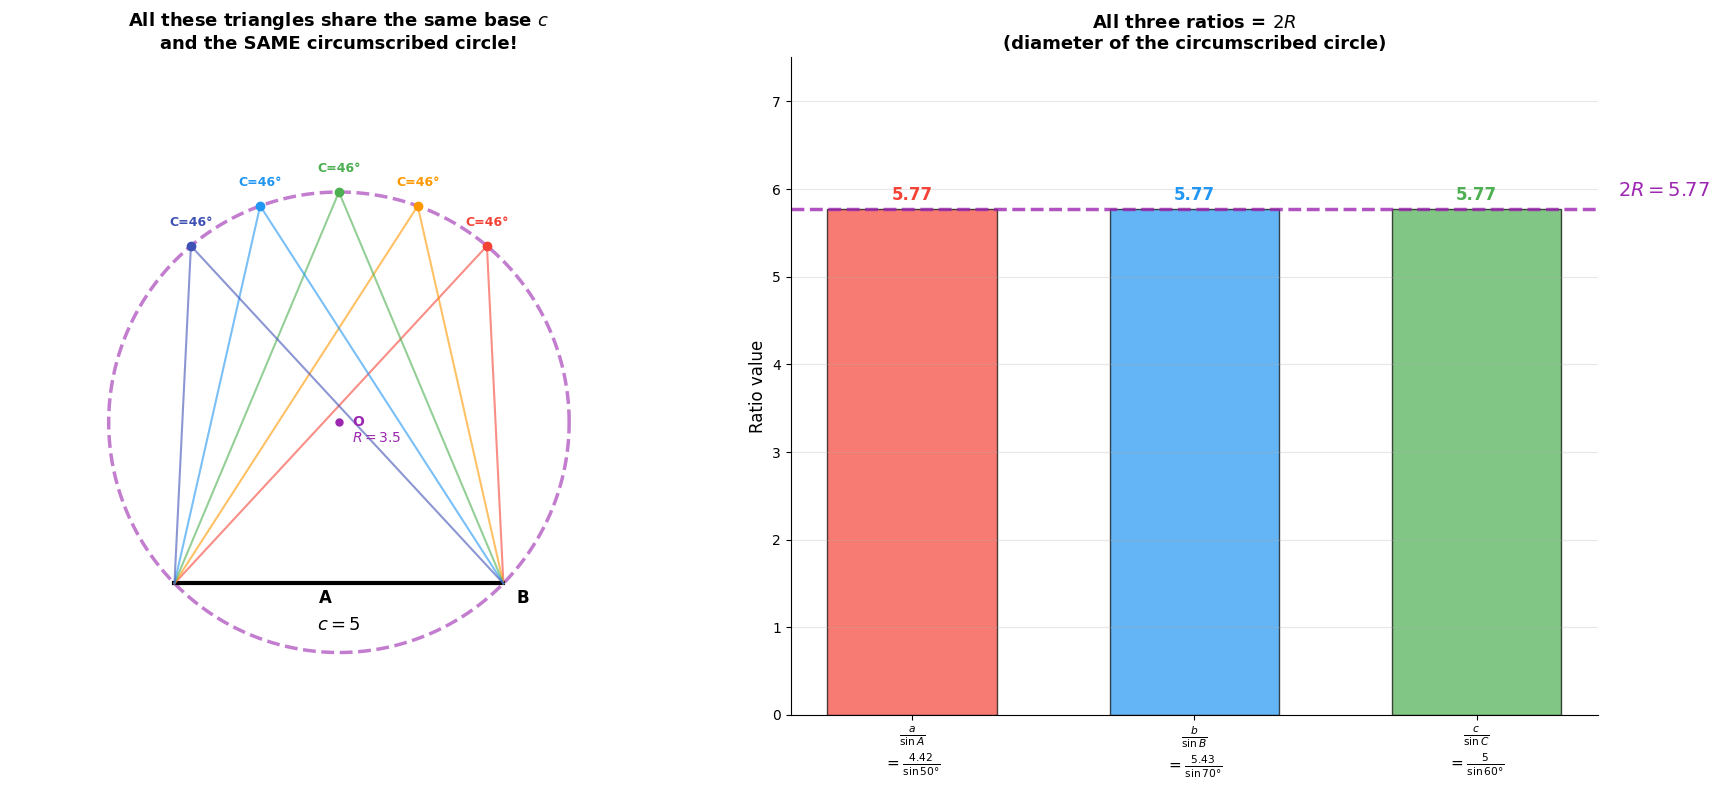

In [20]:
# === DIAGRAM 6: The circumscribed circle — the rotation lives on a circle ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- LEFT: Show multiple triangles on the SAME circle with same base ---
ax = ax1
c_base = 5
# Place A and B on the x-axis
A_pt = np.array([-c_base / 2, 0])
B_pt = np.array([c_base / 2, 0])

# Several different vertex C positions on the same circle
R = 3.5  # circumradius
center = np.array([0, np.sqrt(R**2 - (c_base / 2)**2)])

# Verify: distance from center to A should be R
# np.linalg.norm(center - A_pt) should = R

# Draw the circle
theta_draw = np.linspace(0, 2 * np.pi, 200)
ax.plot(center[0] + R * np.cos(theta_draw), center[1] + R * np.sin(theta_draw),
        '#9C27B0', lw=2.5, ls='--', alpha=0.6)
ax.plot(*center, 'o', color='#9C27B0', ms=5)
ax.text(center[0] + 0.2, center[1] - 0.3, f'O\n$R={R}$', fontsize=10,
        color='#9C27B0', fontweight='bold')

# Draw the fixed base (chord)
ax.plot([A_pt[0], B_pt[0]], [A_pt[1], B_pt[1]], 'k-', lw=3)
ax.text(0, -0.5, f'$c = {c_base}$', fontsize=13, ha='center', va='top', fontweight='bold')

# Several triangles on the circle
C_angles_on_circle = [50, 70, 90, 110, 130]  # angle from center
colors_circ = ['#F44336', '#FF9800', '#4CAF50', '#2196F3', '#3F51B5']

for angle_deg, col in zip(C_angles_on_circle, colors_circ):
    angle_rad = np.radians(angle_deg)
    C_pt = center + R * np.array([np.cos(angle_rad), np.sin(angle_rad)])
    
    # Only if C is above the base
    if C_pt[1] > 0.5:
        ax.plot([A_pt[0], C_pt[0], B_pt[0]], [A_pt[1], C_pt[1], B_pt[1]],
                '-', color=col, lw=1.5, alpha=0.6)
        ax.plot(C_pt[0], C_pt[1], 'o', color=col, ms=6)
        
        # Compute angle C at the vertex
        vec_CA = A_pt - C_pt
        vec_CB = B_pt - C_pt
        cos_C = np.dot(vec_CA, vec_CB) / (np.linalg.norm(vec_CA) * np.linalg.norm(vec_CB))
        angle_C = np.degrees(np.arccos(np.clip(cos_C, -1, 1)))
        ax.text(C_pt[0], C_pt[1] + 0.3, f'C={angle_C:.0f}°', fontsize=9,
                ha='center', color=col, fontweight='bold')

ax.set_xlim(-5, 5)
ax.set_ylim(-2, 8)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('All these triangles share the same base $c$\n'
             'and the SAME circumscribed circle!',
             fontsize=13, fontweight='bold')

ax.text(-0.3, -0.3, 'A', fontsize=12, fontweight='bold')
ax.text(B_pt[0] + 0.2, -0.3, 'B', fontsize=12, fontweight='bold')

# --- RIGHT: Show the ratio a/sin(A) is constant = 2R ---
ax = ax2

# Build one specific triangle
A_deg, B_deg = 50, 70
C_deg = 180 - A_deg - B_deg
A_rad, B_rad, C_rad = np.radians(A_deg), np.radians(B_deg), np.radians(C_deg)

c_len = 5
a_len = c_len * np.sin(A_rad) / np.sin(C_rad)
b_len = c_len * np.sin(B_rad) / np.sin(C_rad)

R_val = a_len / (2 * np.sin(A_rad))

# Bar chart: the three ratios
ratios = [a_len / np.sin(A_rad), b_len / np.sin(B_rad), c_len / np.sin(C_rad)]
bar_labels = [f'$\\frac{{a}}{{\\sin A}}$\n$= \\frac{{{a_len:.2f}}}{{\\sin {A_deg}°}}$',
              f'$\\frac{{b}}{{\\sin B}}$\n$= \\frac{{{b_len:.2f}}}{{\\sin {B_deg}°}}$',
              f'$\\frac{{c}}{{\\sin C}}$\n$= \\frac{{{c_len}}}{{\\sin {C_deg}°}}$']
bar_colors = ['#F44336', '#2196F3', '#4CAF50']

bars = ax.bar(range(3), ratios, color=bar_colors, edgecolor='black', width=0.6, alpha=0.7)

# 2R line
ax.axhline(2 * R_val, color='#9C27B0', ls='--', lw=2.5, alpha=0.8)
ax.text(2.5, 2 * R_val + 0.15, f'$2R = {2 * R_val:.2f}$', fontsize=14,
        color='#9C27B0', fontweight='bold')

# Value labels on bars
for j, (r, c) in enumerate(zip(ratios, bar_colors)):
    ax.text(j, r + 0.1, f'{r:.2f}', ha='center', fontsize=12, fontweight='bold', color=c)

ax.set_xticks(range(3))
ax.set_xticklabels(bar_labels, fontsize=11)
ax.set_ylim(0, max(ratios) * 1.3)
ax.set_ylabel('Ratio value', fontsize=12)
ax.set_title('All three ratios = $2R$\n(diameter of the circumscribed circle)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7 — The Formal Proof (From the Rotating Rods)

Now the algebra, which follows directly from the "rotating rods" intuition:

**Setup:** Triangle with vertices $A$, $B$, $C$. Drop a perpendicular from $C$ to side $c$ (the base).

**Two rods reach vertex $C$:**
- Rod $b$ (from $A$): its vertical reach = $b \sin(A)$
- Rod $a$ (from $B$): its vertical reach = $a \sin(B)$

**Same vertex $C$ → same height $h$:**

$$h = b \sin(A) = a \sin(B)$$

**Rearrange** (divide both sides by $\sin A \cdot \sin B$):

$$\frac{b}{\sin B} = \frac{a}{\sin A}$$

Or equivalently: $\boxed{\frac{a}{\sin A} = \frac{b}{\sin B}}$

**Repeat** by dropping the perpendicular from $A$ to side $a$, or from $B$ to side $b$, and you get:

$$\boxed{\frac{a}{\sin A} = \frac{b}{\sin B} = \frac{c}{\sin C} = 2R}$$

Compare with the Law of Cosines proof:
- **Cosines:** Drop a perpendicular, get two horizontal pieces ($b\cos\theta$ and $a - b\cos\theta$), apply Pythagorean theorem → $c^2 = a^2 + b^2 - 2ab\cos\theta$
- **Sines:** Drop the same perpendicular, equate two vertical heights ($b\sin A = a\sin B$), rearrange → $\frac{a}{\sin A} = \frac{b}{\sin B}$

Same perpendicular, two different truths — horizontal gives Cosines, vertical gives Sines. ✅

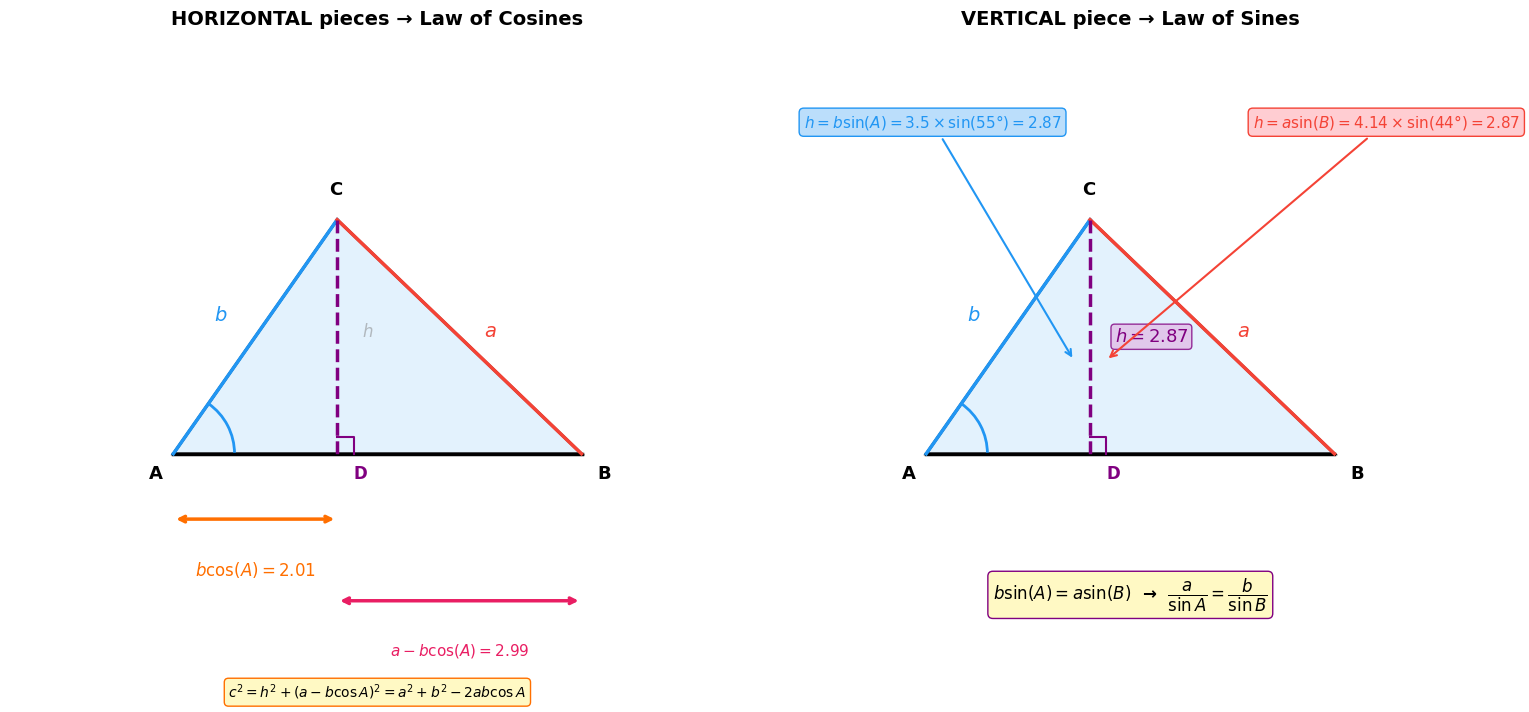

In [21]:
# === DIAGRAM 7: Side-by-side — the SAME perpendicular gives BOTH laws ===

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

a_len_f, b_len_f = 5, 3.5
theta_deg = 55
theta = np.radians(theta_deg)

A_pt = np.array([0, 0])
B_pt = np.array([a_len_f, 0])
C_pt = np.array([b_len_f * np.cos(theta), b_len_f * np.sin(theta)])
foot = np.array([C_pt[0], 0])
h = b_len_f * np.sin(theta)
b_proj = b_len_f * np.cos(theta)
remaining = a_len_f - b_proj
c_val = np.linalg.norm(B_pt - C_pt)

# Compute angle B
B_angle = np.arctan2(C_pt[1], B_pt[0] - C_pt[0])
B_deg = np.degrees(B_angle)

for ax, title, focus in [(ax1, 'HORIZONTAL pieces → Law of Cosines', 'cosines'),
                          (ax2, 'VERTICAL piece → Law of Sines', 'sines')]:
    ax.set_xlim(-2, 7)
    ax.set_ylim(-3, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # Draw triangle
    ax.add_patch(plt.Polygon([A_pt, B_pt, C_pt], fc='#E3F2FD', ec='black', lw=2))
    ax.plot([A_pt[0], B_pt[0]], [A_pt[1], B_pt[1]], 'k-', lw=2.5)
    ax.plot([A_pt[0], C_pt[0]], [A_pt[1], C_pt[1]], '#2196F3', lw=2.5)
    ax.plot([B_pt[0], C_pt[0]], [B_pt[1], C_pt[1]], '#F44336', lw=2.5)
    
    # The perpendicular (same in both!)
    ax.plot([C_pt[0], foot[0]], [C_pt[1], 0], 'purple', lw=2.5, ls='--')
    sq = 0.2
    ax.plot([foot[0] + sq, foot[0] + sq, foot[0]], [0, sq, sq], 'purple', lw=1.5)
    
    # Vertex labels
    ax.text(-0.3, -0.3, 'A', fontsize=13, fontweight='bold')
    ax.text(a_len_f + 0.2, -0.3, 'B', fontsize=13, fontweight='bold')
    ax.text(C_pt[0] - 0.1, C_pt[1] + 0.3, 'C', fontsize=13, fontweight='bold')
    ax.text(foot[0] + 0.2, -0.3, 'D', fontsize=12, fontweight='bold', color='purple')
    
    # Side labels
    mid_b = (A_pt + C_pt) / 2
    ax.text(mid_b[0] - 0.5, mid_b[1] + 0.2, '$b$', fontsize=14,
            fontweight='bold', color='#2196F3')
    mid_a = (B_pt + C_pt) / 2
    ax.text(mid_a[0] + 0.3, mid_a[1], '$a$', fontsize=14, fontweight='bold', color='#F44336')
    
    # Angle arc at A
    arc_A = patches.Arc(A_pt, 1.5, 1.5, angle=0, theta1=0, theta2=theta_deg,
                        lw=2, color='#2196F3')
    ax.add_patch(arc_A)
    
    if focus == 'cosines':
        # Highlight HORIZONTAL pieces
        # b·cos(θ)
        ax.annotate('', xy=(b_proj, -0.8), xytext=(0, -0.8),
                    arrowprops=dict(arrowstyle='<->', color='#FF6F00', lw=2.5))
        ax.text(b_proj / 2, -1.3, f'$b\\cos(A) = {b_proj:.2f}$',
                fontsize=12, ha='center', va='top', color='#FF6F00', fontweight='bold')
        
        # a - b·cos(θ)
        ax.annotate('', xy=(a_len_f, -1.8), xytext=(b_proj, -1.8),
                    arrowprops=dict(arrowstyle='<->', color='#E91E63', lw=2.5))
        ax.text((a_len_f + b_proj) / 2, -2.3, f'$a - b\\cos(A) = {remaining:.2f}$',
                fontsize=11, ha='center', va='top', color='#E91E63', fontweight='bold')
        
        # Result
        ax.text(2.5, -2.8,
                f'$c^2 = h^2 + (a - b\\cos A)^2 = a^2 + b^2 - 2ab\\cos A$',
                fontsize=10, ha='center', va='top',
                bbox=dict(fc='#FFF9C4', ec='#FF6F00', boxstyle='round,pad=0.3'))
        
        # Dim the height
        ax.text(C_pt[0] + 0.3, h / 2, f'$h$', fontsize=12, color='gray', alpha=0.5)
        
    else:  # sines
        # Highlight VERTICAL piece
        ax.text(C_pt[0] + 0.3, h / 2, f'$h = {h:.2f}$',
                fontsize=13, ha='left', va='center', color='purple', fontweight='bold',
                bbox=dict(fc='#E1BEE7', ec='purple', boxstyle='round,pad=0.2', alpha=0.8))
        
        # Two ways to compute h
        ax.annotate(f'$h = b\\sin(A) = {b_len_f} \\times \\sin({theta_deg}°) = {h:.2f}$',
                    xy=(C_pt[0] - 0.2, h * 0.4), xytext=(-1.5, 4),
                    fontsize=11, color='#2196F3', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5),
                    bbox=dict(fc='#BBDEFB', ec='#2196F3', boxstyle='round,pad=0.3'))
        
        ax.annotate(f'$h = a\\sin(B) = {c_val:.2f} \\times \\sin({B_deg:.0f}°) = {c_val * np.sin(B_angle):.2f}$',
                    xy=(C_pt[0] + 0.2, h * 0.4), xytext=(4, 4),
                    fontsize=11, color='#F44336', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5),
                    bbox=dict(fc='#FFCDD2', ec='#F44336', boxstyle='round,pad=0.3'))
        
        # Result
        ax.text(2.5, -1.5,
                f'$b\\sin(A) = a\\sin(B)$  →  $\\dfrac{{a}}{{\\sin A}} = \\dfrac{{b}}{{\\sin B}}$',
                fontsize=12, ha='center', va='top', fontweight='bold',
                bbox=dict(fc='#FFF9C4', ec='purple', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

## Step 8 — Numerical Verification

Let's verify the Law of Sines with concrete numbers, just like we did for Cosines.

In [22]:
# === Numerical verification ===

print("Law of Sines: a/sin(A) = b/sin(B) = c/sin(C) = 2R")
print("The 'rotating rods' must reach the same height!")
print("=" * 70)

test_cases = [
    (40, 60, "Acute triangle"),
    (30, 60, "30-60-90 right triangle"),
    (45, 45, "Isosceles right triangle"),
    (20, 130, "Obtuse triangle"),
    (60, 60, "Equilateral triangle"),
    (10, 80, "Very skewed triangle"),
]

for A_deg, B_deg, name in test_cases:
    C_deg = 180 - A_deg - B_deg
    A_r, B_r, C_r = np.radians(A_deg), np.radians(B_deg), np.radians(C_deg)
    
    # Build triangle with c = 10
    c = 10
    a = c * np.sin(A_r) / np.sin(C_r)
    b = c * np.sin(B_r) / np.sin(C_r)
    
    # Height from C to base c
    h_from_b = b * np.sin(A_r)
    h_from_a = a * np.sin(B_r)
    
    # Ratios
    r_a = a / np.sin(A_r)
    r_b = b / np.sin(B_r)
    r_c = c / np.sin(C_r)
    
    print(f"\n{name} (A={A_deg}°, B={B_deg}°, C={C_deg}°)")
    print(f"  Sides: a={a:.3f}, b={b:.3f}, c={c}")
    print(f"  Height check: b·sin(A) = {h_from_b:.4f},  a·sin(B) = {h_from_a:.4f}  ← Same! ✓")
    print(f"  a/sin(A) = {r_a:.4f}")
    print(f"  b/sin(B) = {r_b:.4f}")
    print(f"  c/sin(C) = {r_c:.4f}  ← All equal = 2R")

print("\n" + "=" * 70)
print("\n✅ b·sin(A) = a·sin(B) always — the two rods reach the same height")
print("✅ a/sin(A) = b/sin(B) = c/sin(C) — the ratio is constant = 2R")
print("✅ At 90°: sin(90°) = 1, so the side IS the height (no rescaling needed)")

Law of Sines: a/sin(A) = b/sin(B) = c/sin(C) = 2R
The 'rotating rods' must reach the same height!

Acute triangle (A=40°, B=60°, C=80°)
  Sides: a=6.527, b=8.794, c=10
  Height check: b·sin(A) = 5.6526,  a·sin(B) = 5.6526  ← Same! ✓
  a/sin(A) = 10.1543
  b/sin(B) = 10.1543
  c/sin(C) = 10.1543  ← All equal = 2R

30-60-90 right triangle (A=30°, B=60°, C=90°)
  Sides: a=5.000, b=8.660, c=10
  Height check: b·sin(A) = 4.3301,  a·sin(B) = 4.3301  ← Same! ✓
  a/sin(A) = 10.0000
  b/sin(B) = 10.0000
  c/sin(C) = 10.0000  ← All equal = 2R

Isosceles right triangle (A=45°, B=45°, C=90°)
  Sides: a=7.071, b=7.071, c=10
  Height check: b·sin(A) = 5.0000,  a·sin(B) = 5.0000  ← Same! ✓
  a/sin(A) = 10.0000
  b/sin(B) = 10.0000
  c/sin(C) = 10.0000  ← All equal = 2R

Obtuse triangle (A=20°, B=130°, C=30°)
  Sides: a=6.840, b=15.321, c=10
  Height check: b·sin(A) = 5.2401,  a·sin(B) = 5.2401  ← Same! ✓
  a/sin(A) = 20.0000
  b/sin(B) = 20.0000
  c/sin(C) = 20.0000  ← All equal = 2R

Equilateral tri

## Summary — The Dual of the Cosines Proof

The Law of Sines is the **vertical twin** of the Law of Cosines:

$$\frac{a}{\sin A} = \frac{b}{\sin B} = \frac{c}{\sin C} = 2R$$

Your intuition, step by step:

1. **Start at 90°**: When a side is perpendicular to the base, its full length IS the height ($\sin 90° = 1$)
2. **Tilt away from 90°**: $\sin(\text{angle})$ rescales the side — you lose height, just like $\cos(\theta)$ lost horizontal projection in the Cosines proof
3. **Two rotating rods**: Side $b$ rotates from $A$, side $a$ rotates from $B$, on two different circles
4. **They must meet**: Their tips meet at vertex $C$ → same height → $b\sin(A) = a\sin(B)$
5. **The trade-off**: A shorter rod needs a bigger angle (closer to 90°) to reach the same height, a longer rod can get away with a smaller angle
6. **The constant $2R$**: The ratio $\frac{\text{side}}{\sin(\text{angle})}$ is the diameter of the circumscribed circle — the circle enforces the balance

| Law | Same perpendicular | What it measures | Rescaler | Formula |
|:--|:--|:--|:-:|:--|
| **Cosines** | Horizontal pieces | How much of $b$ aligns with $a$ | $\cos(\theta)$ | $c^2 = a^2 + b^2 - 2ab\cos\theta$ |
| **Sines** | Vertical piece (height) | How much of $b$ reaches straight up | $\sin(\theta)$ | $\frac{a}{\sin A} = \frac{b}{\sin B}$ |

Two sides of the same perpendicular. $\cos$ gives the horizontal story, $\sin$ gives the vertical story. Together, they tell you everything about the triangle. ✅